# White Box - Supervised ML Project
__Name:__ Ali Hasan

__Topic Name:__ Classification Topic

## Introduction
We work for a finance company that wants to automate credit score classification.
Right now, the process is manual — employees read credit data and decide whether a customer’s credit score is Good, Standard, or Poor.

### Problem Statement
You are working as a data scientist in a global finance company. Over the years, the company has collected basic bank details and gathered a lot of credit-related information. The management wants to build an intelligent system to segregate the people into credit score brackets to reduce the manual efforts.


### Objectives
List the key questions guiding your analysis and modeling:
- What features influence the target variable?
- Can feature engineering improve model performance?
- How do different model versions compare?


## Data Overview
__Load and inspect the dataset__
- Source and format
- .head(), .info(), .describe(),…


In [48]:
import pandas as pd

# Load the dataset
df = pd.read_csv("train.csv")

# Inspect structure
df.head()


C:\Users\ali.habib\AppData\Local\Temp\ipykernel_27628\2047055805.py:4: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [49]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [50]:
df.describe(include='all')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,84998.000000,100000.000000,...,100000,100000,100000.000000,90970,100000,100000.000000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,NaN,NaN,...,4,13178,NaN,404,3,NaN,91049,7,98792,3
top,0x1602,CUS_0xd40,January,Langep,38,#F%$D@*&8,_______,36585.12,NaN,NaN,...,Standard,1360.45,NaN,15 Years and 11 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,NaN,NaN,...,36479,24,NaN,446,52326,NaN,4305,25513,9,53174
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4194.170850,17.091280,...,NaN,NaN,32.285173,NaN,NaN,1403.118217,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.686167,117.404834,...,NaN,NaN,5.116875,NaN,NaN,8306.041270,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,...,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1625.568229,3.000000,...,NaN,NaN,28.052567,NaN,NaN,30.306660,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3093.745000,6.000000,...,NaN,NaN,32.305784,NaN,NaN,69.249473,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5957.448333,7.000000,...,NaN,NaN,36.496663,NaN,NaN,161.224249,NaN,NaN,NaN,NaN


In [51]:
df['Payment_Behaviour'].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      25513
High_spent_Medium_value_payments    17540
Low_spent_Medium_value_payments     13861
High_spent_Large_value_payments     13721
High_spent_Small_value_payments     11340
Low_spent_Large_value_payments      10425
!@9#%8                               7600
Name: count, dtype: int64

## Data Cleaning
__Handle missing values, outliers, and inconsistencies__
- Rename columns
- Fix data types
- Document assumptions


In [52]:
import numpy as np


df.replace(['_','_______', 'NA', '!@9#%8', '#F%$D@*&8', '__10000__', '__-333333333333333333333333333__'], np.nan, inplace=True)



In [53]:
df.describe(include='all')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,94428,92938,100000,84998.000000,100000.000000,...,79805,100000,100000.000000,90970,100000,100000.000000,91216,92400,98791,100000
unique,100000,12500,8,10139,1788,12500,15,18940,NaN,NaN,...,3,13178,NaN,404,3,NaN,91048,6,98791,3
top,0x1602,CUS_0xd40,January,Langep,38,078-73-5990,Lawyer,36585.12,NaN,NaN,...,Standard,1360.45,NaN,15 Years and 11 Months,Yes,NaN,0.0,Low_spent_Small_value_payments,312.49408867943663,Standard
freq,1,8,12500,44,2833,8,6575,16,NaN,NaN,...,36479,24,NaN,446,52326,NaN,169,25513,1,53174
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4194.170850,17.091280,...,NaN,NaN,32.285173,NaN,NaN,1403.118217,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.686167,117.404834,...,NaN,NaN,5.116875,NaN,NaN,8306.041270,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,...,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1625.568229,3.000000,...,NaN,NaN,28.052567,NaN,NaN,30.306660,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3093.745000,6.000000,...,NaN,NaN,32.305784,NaN,NaN,69.249473,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5957.448333,7.000000,...,NaN,NaN,36.496663,NaN,NaN,161.224249,NaN,NaN,NaN,NaN


In [54]:
#Convert the column to months

def convert_to_months(text):
    if pd.isna(text): return np.nan
    parts = text.split()
    years = int(parts[0])
    months = int(parts[3])
    return years * 12 + months

df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_to_months)



In [55]:
numeric_cols = ['Age', 'Annual_Income', 'Outstanding_Debt', 'Changed_Credit_Limit', 'Amount_invested_monthly', 'Monthly_Balance','Credit_History_Age']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [ ]:
#Drop rows with invalid ages
df = df[df['Age'] > 0 & df['Age'] < 80]
df.drop(columns=['ID','Name','SSN'],inplace=True)

In [57]:
df.drop(columns=['Type_of_Loan'],inplace=True)

In [58]:
df.isna().sum()


Customer_ID                     0
Month                           0
Age                             0
Occupation                   6671
Annual_Income                6615
Monthly_Inhand_Salary       14139
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Delay_from_due_date             0
Num_of_Delayed_Payment       6590
Changed_Credit_Limit         1967
Num_Credit_Inquiries         1853
Credit_Mix                  19021
Outstanding_Debt              953
Credit_Utilization_Ratio        0
Credit_History_Age           8495
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      8270
Payment_Behaviour            7164
Monthly_Balance              1140
Credit_Score                    0
dtype: int64

In [59]:
df['Customer_ID'].describe()

count          94175
unique         12500
top       CUS_0x2646
freq               8
Name: Customer_ID, dtype: object

In [60]:
# Map month names to order for per-customer filling
month_order = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
               'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
df['MonthNum'] = df['Month'].map(month_order)
df = df.sort_values(['Customer_ID', 'MonthNum'])


In [61]:
num_cols_key = [
    'Annual_Income', 'Monthly_Inhand_Salary', 'Num_of_Delayed_Payment',
    'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt',
    'Credit_History_Age', 'Amount_invested_monthly', 'Monthly_Balance'
]



In [62]:
# Numeric columns to ffill/bfill within customer
numeric_cols = [
    'Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card',
    'Interest_Rate','Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment',
    'Changed_Credit_Limit','Num_Credit_Inquiries','Outstanding_Debt',
    'Credit_Utilization_Ratio','Credit_History_Age','Total_EMI_per_month',
    'Amount_invested_monthly','Monthly_Balance'
]

# Categorical columns to ffill/bfill within customer
cat_cols = [
    'Occupation','Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour','Month'
]

# Groupwise fill to exploit temporal consistency
df[numeric_cols] = df.groupby('Customer_ID')[numeric_cols].ffill()
df[numeric_cols] = df.groupby('Customer_ID')[numeric_cols].bfill()

df[cat_cols] = df.groupby('Customer_ID')[cat_cols].ffill()
df[cat_cols] = df.groupby('Customer_ID')[cat_cols].bfill()


In [69]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,MonthNum
count,94175.000000,9.417500e+04,94175.000000,94175.000000,94175.000000,94175.000000,94175.000000,94175.000000,94175.000000,94175.000000,94175.000000,94175.000000,94175.000000,94175.000000,94175.000000,94175.000000
mean,116.682187,1.813385e+05,4199.900255,17.194170,22.483239,72.293900,21.056289,10.387854,27.719267,1426.487862,32.288286,221.133379,1392.662117,195.800065,403.080803,4.499889
std,690.079845,1.459227e+06,3184.738483,117.782825,129.110554,465.523852,14.849839,6.784286,192.877402,1154.669883,5.116921,99.586315,8267.575190,199.452202,214.788782,2.290969
min,14.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,-5.000000,-6.490000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760,1.000000
25%,25.000000,1.948853e+04,1628.569167,3.000000,4.000000,8.000000,10.000000,5.320000,3.000000,566.860000,28.052581,145.000000,30.338701,72.437283,270.003672,3.000000
50%,33.000000,3.765418e+04,3101.080414,6.000000,5.000000,13.000000,18.000000,9.400000,6.000000,1166.910000,32.313152,219.000000,69.284467,129.220009,337.099107,5.000000
75%,42.000000,7.284132e+04,5966.625000,7.000000,7.000000,20.000000,28.000000,14.860000,9.000000,1946.810000,36.498290,302.000000,161.292233,237.128026,471.616803,7.000000
max,8698.000000,2.419806e+07,15204.633333,1798.000000,1499.000000,5797.000000,67.000000,36.970000,2597.000000,4998.070000,50.000000,404.000000,82331.000000,1977.326102,1602.040519,8.000000


In [71]:
df.rename(columns={'Monthly_Inhand_Salary': 'MonthlySalary'}, inplace=True)

In [72]:

# Age filter
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

# Non-negative financials
for col in ['Annual_Income','MonthlySalary','Outstanding_Debt','Monthly_Balance']:
    df = df[df[col] >= 0]

# Credit utilization ratio sanity check
df = df[(df['Credit_Utilization_Ratio'] >= 0) & (df['Credit_Utilization_Ratio'] <= 100)]

In [73]:
df.shape

(86937, 25)

In [74]:
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

# Apply to selected numeric columns
for col in ['Annual_Income','MonthlySalary','Outstanding_Debt','Monthly_Balance','Total_EMI_per_month']:
    df = remove_outliers_iqr(df, col)


In [75]:
df.shape

(68405, 25)

## Exploratory Data Analysis (EDA)
### Analysis
__Answer objectives using visual and statistical insights__
- Trends, relationships, anomalies
- Outlier and missing values treatment
- Univariate, bivariate, or multivariate analysis
    - Histograms, box plots, bar charts
    - Correlation matrix for continuous columns (required if applicable)


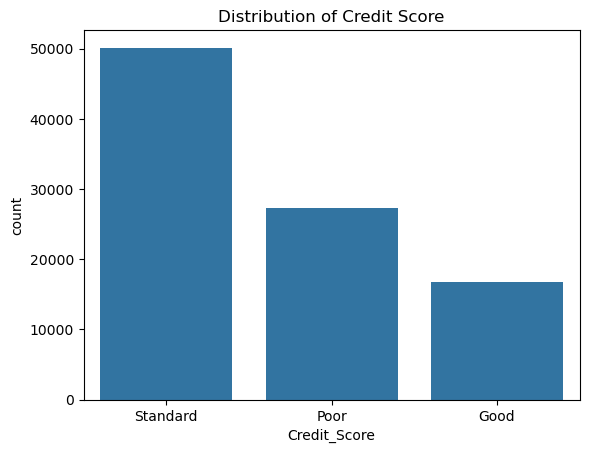

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of Credit Score
sns.countplot(x='Credit_Score', data=df, order=df['Credit_Score'].value_counts().index)
plt.title("Distribution of Credit Score")
plt.show()


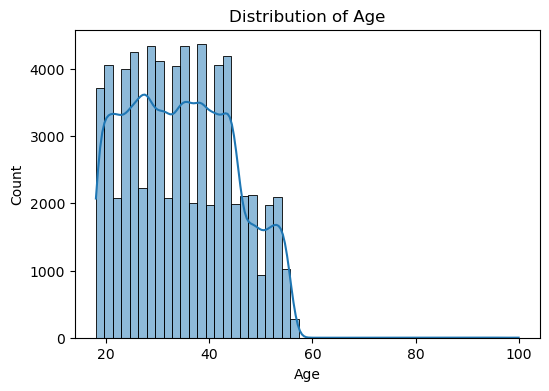

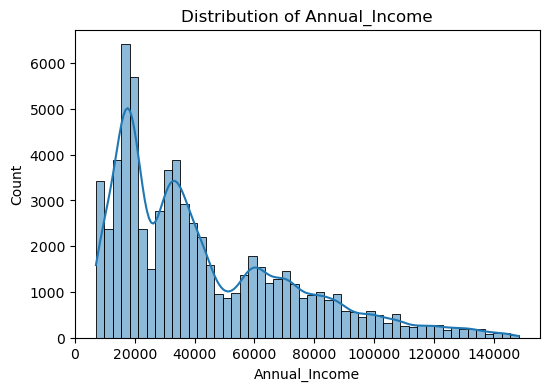

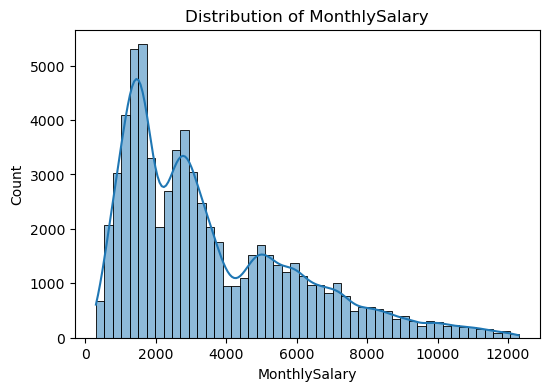

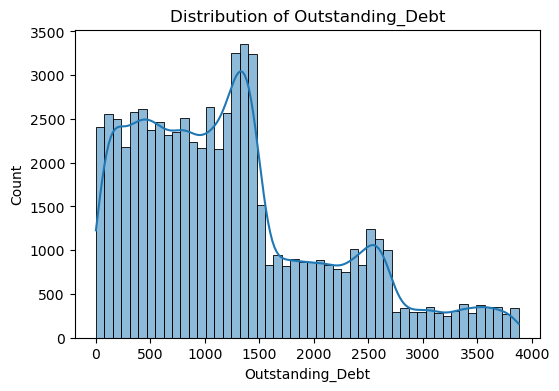

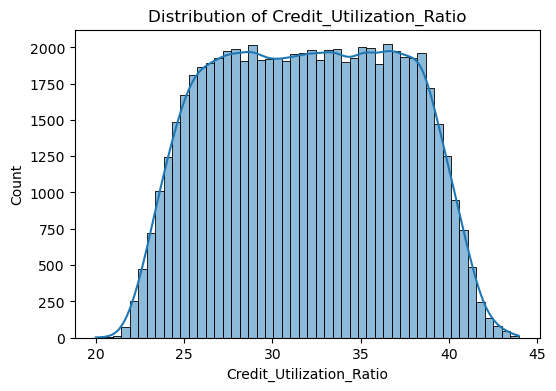

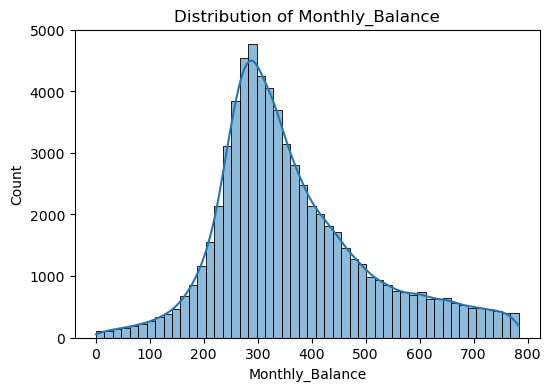

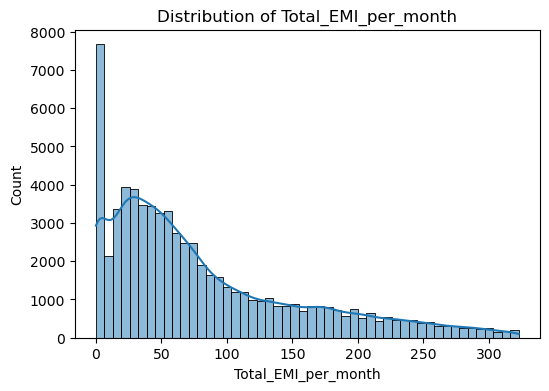

In [76]:
num_cols = [
    'Age','Annual_Income','MonthlySalary','Outstanding_Debt',
    'Credit_Utilization_Ratio','Monthly_Balance','Total_EMI_per_month'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


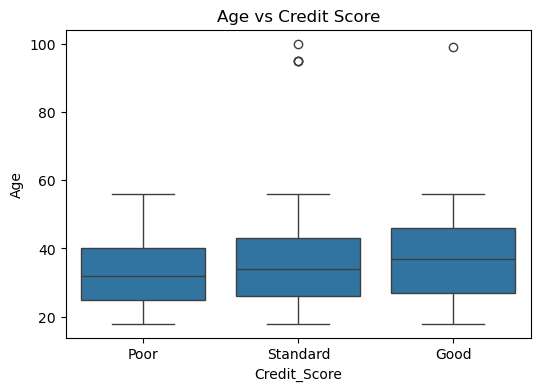

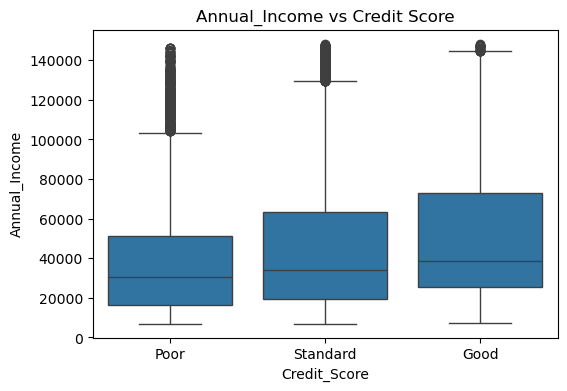

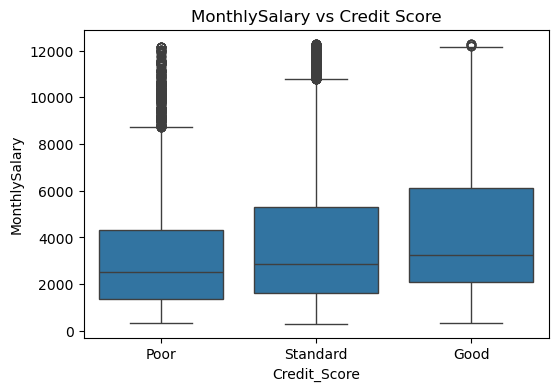

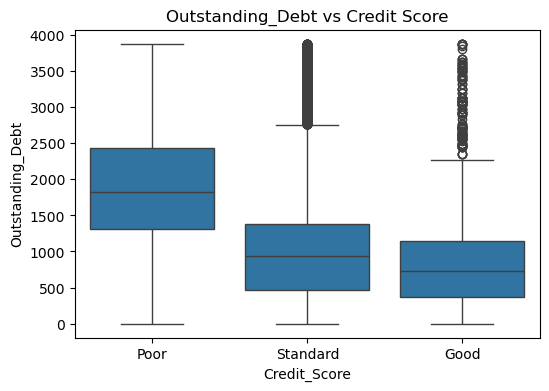

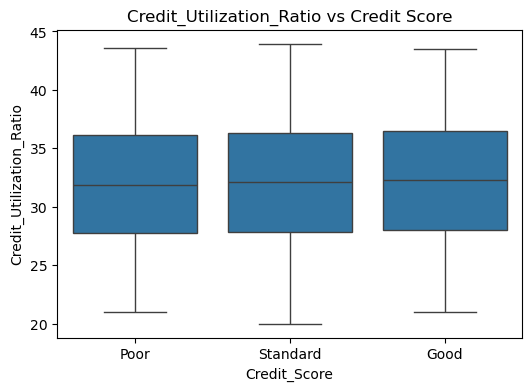

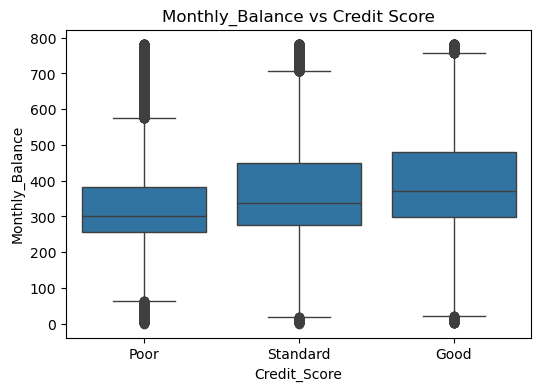

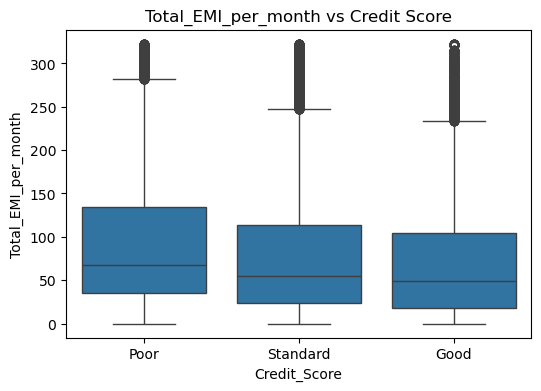

In [77]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Credit_Score', y=col, data=df)
    plt.title(f"{col} vs Credit Score")
    plt.show()


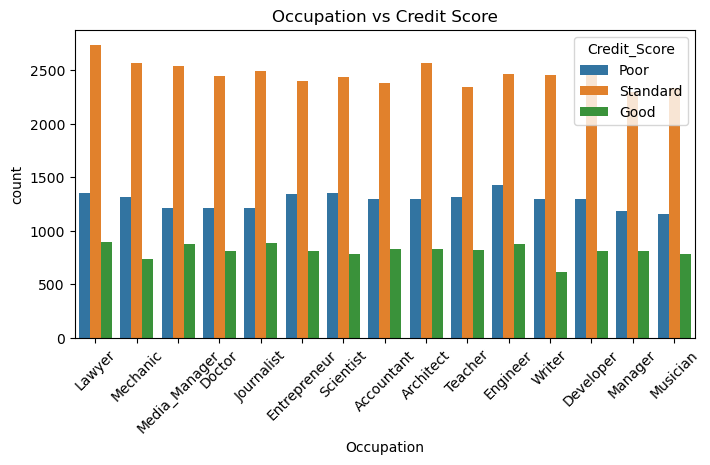

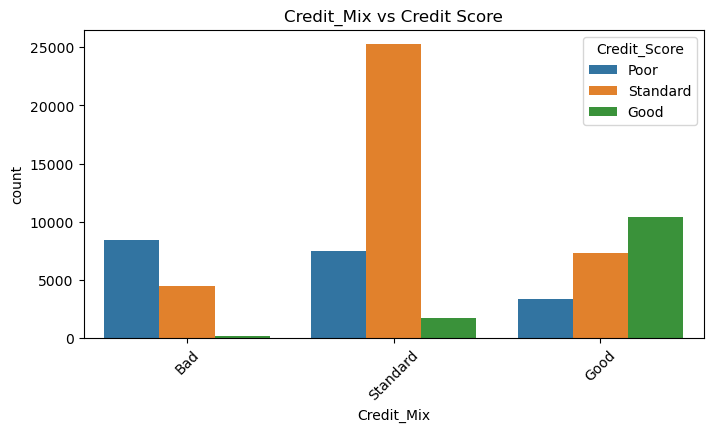

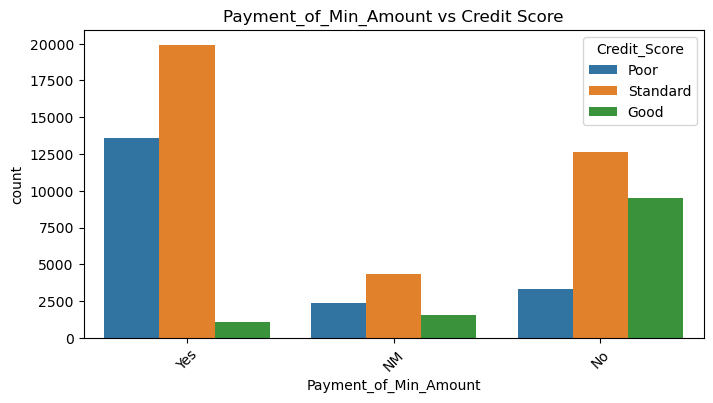

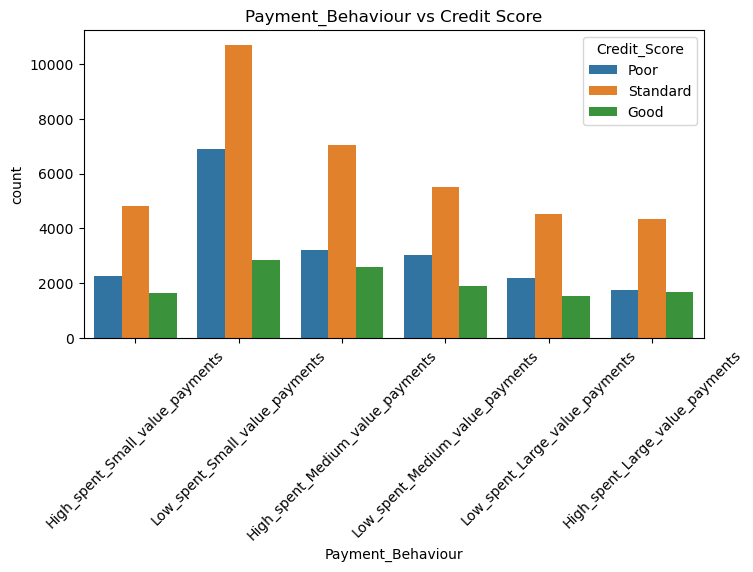

In [78]:
cat_cols = ['Occupation','Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='Credit_Score', data=df)
    plt.title(f"{col} vs Credit Score")
    plt.xticks(rotation=45)
    plt.show()

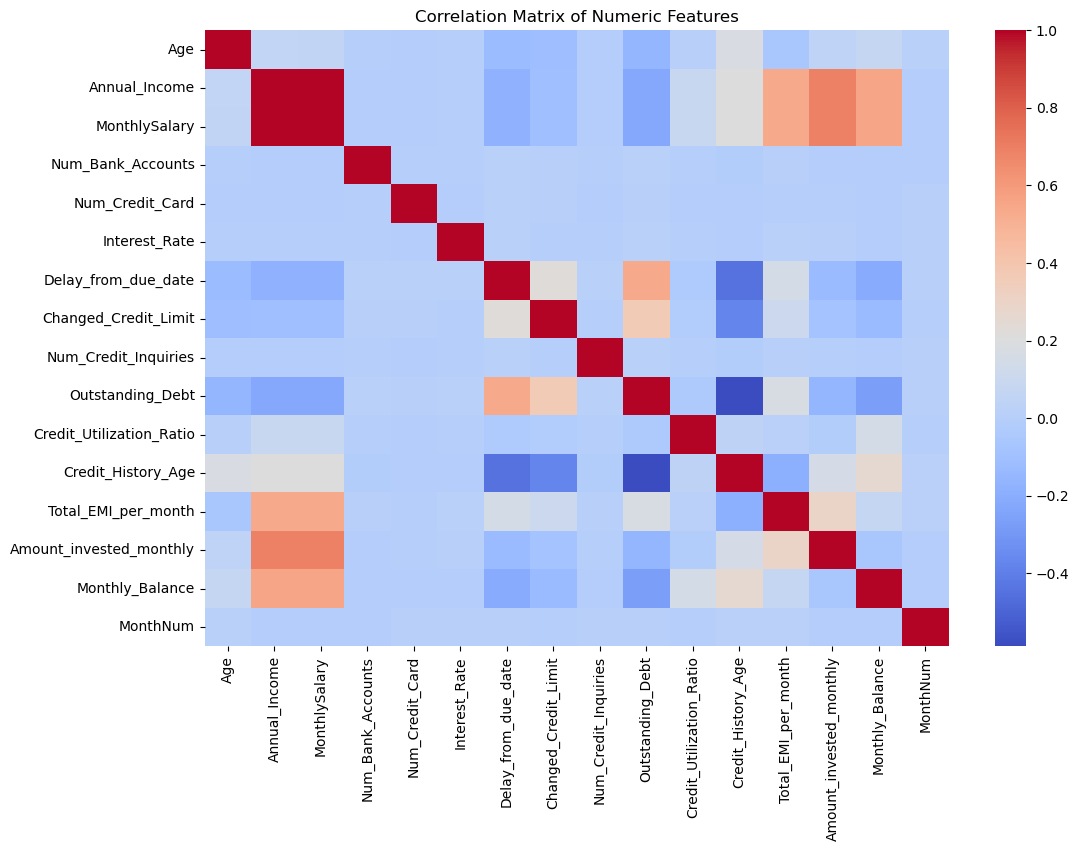

In [79]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=['float64','int64']).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features")
plt.show()

### Data Handling for Modeling
- __Transform, encode, and prepare features__
    - Categorical encoding
    - Feature scaling (especially for KNN)


## Model Building
__Build and compare two models for your topic__
### Model 1: Linear / Logistic Regression
- Version 1: baseline
- Version 2: modified features or tuned parameters
- Checking if model assumptions were met
 ...


In [81]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
df_model = df.copy()

In [82]:
# Label encode target
le = LabelEncoder()
df_model['Credit_Score'] = le.fit_transform(df_model['Credit_Score']) 

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68405 entries, 56757 to 99159
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               68405 non-null  object 
 1   Month                     68405 non-null  object 
 2   Age                       68405 non-null  float64
 3   Occupation                68405 non-null  object 
 4   Annual_Income             68405 non-null  float64
 5   MonthlySalary             68405 non-null  float64
 6   Num_Bank_Accounts         68405 non-null  int64  
 7   Num_Credit_Card           68405 non-null  int64  
 8   Interest_Rate             68405 non-null  int64  
 9   Num_of_Loan               68405 non-null  object 
 10  Delay_from_due_date       68405 non-null  int64  
 11  Num_of_Delayed_Payment    68401 non-null  object 
 12  Changed_Credit_Limit      68405 non-null  float64
 13  Num_Credit_Inquiries      68405 non-null  float64
 14  Credit_

In [83]:
# One-hot encode categorical features
df_model = pd.get_dummies(df_model, 
                          columns=['Occupation','Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour'], 
                          drop_first=True)


In [85]:
# Version 1: Basic features (small set)
features_v1 = ['Age','Annual_Income','MonthlySalary','Outstanding_Debt']

# Version 2: Extended features (larger set)
features_v2 = [
    'Age','Annual_Income','MonthlySalary','Outstanding_Debt',
    'Num_Bank_Accounts','Num_Credit_Card','Interest_Rate',
    'Delay_from_due_date','Num_Credit_Inquiries','Credit_Utilization_Ratio',
    'Total_EMI_per_month','Monthly_Balance'
]



In [98]:
X1 = df[features_v1]
X2 = df[features_v2]
y = df['Credit_Score']
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42, stratify=y)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42, stratify=y)


In [99]:

scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)


### Model Evaluation
__Use appropriate metrics based on task type and compare between the Models and their versions__

__For Regression:__
- R² Score
- Root Mean Squared Error (RMSE)
- Residual plots


### Model 2: KNN Regressor / KNN Classifier
- Version 1: baseline
- Version 2: modified features or tuned parameters
- Checking if model assumptions were met 
 ...


__For Classification:__
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC _**(Optional)**_
- Confusion Matrix

_Include visualizations and interpretation for each metric._


In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
def evaluate_model_metrics(model, X_train, y_train, X_test, y_test, name):
    """Evaluate model on train and test sets with key classification metrics"""
    print(f"\n=== {name} ===")
    
    # Train predictions
    y_train_pred = model.predict(X_train)
    # Test predictions
    y_test_pred = model.predict(X_test)
    
    # Train metrics
    print("Train Metrics:")
    print(" Accuracy :", accuracy_score(y_train, y_train_pred))
    print(" Precision:", precision_score(y_train, y_train_pred, average='weighted'))
    print(" Recall   :", recall_score(y_train, y_train_pred, average='weighted'))
    print(" F1 Score :", f1_score(y_train, y_train_pred, average='weighted'))

    print(" Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
    
    # Test metrics
    print("\nTest Metrics:")
    print(" Accuracy :", accuracy_score(y_test, y_test_pred))
    print(" Precision:", precision_score(y_test, y_test_pred, average='weighted'))
    print(" Recall   :", recall_score(y_test, y_test_pred, average='weighted'))
    print(" F1 Score :", f1_score(y_test, y_test_pred, average='weighted'))

    print(" Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
    

In [101]:
# Logistic Regression V1 (few features)
from sklearn.linear_model import LogisticRegression


lr_v1 = LogisticRegression(max_iter=1000)
lr_v1.fit(X1_train, y_train)
evaluate_model_metrics(lr_v1, X1_train, y_train, X1_test, y_test, "Logistic Regression V1")

# Logistic Regression V2 (more features)
lr_v2 = LogisticRegression(max_iter=1000)
lr_v2.fit(X2_train, y_train)
evaluate_model_metrics(lr_v2, X2_train, y_train, X2_test, y_test, "Logistic Regression V2")

# KNN V1 (few features, scaled)
knn_v1 = KNeighborsClassifier(n_neighbors=5)
knn_v1.fit(X1_train_scaled, y_train)
evaluate_model_metrics(knn_v1, X1_train_scaled, y_train, X1_test_scaled, y_test, "KNN V1")

# KNN V2 (more features, scaled)
knn_v2 = KNeighborsClassifier(n_neighbors=7)
knn_v2.fit(X2_train_scaled, y_train)
evaluate_model_metrics(knn_v2, X2_train_scaled, y_train, X2_test_scaled, y_test, "KNN V2")

c:\Users\ali.habib\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression V1 ===
Train Metrics:
 Accuracy : 0.5809882318543966
 Precision: 0.5310266585587922
 Recall   : 0.5809882318543966
 F1 Score : 0.508827050836029
 Confusion Matrix:
 [[    5   127  9616]
 [    1  6068  9352]
 [   12  3822 25721]]

Test Metrics:
 Accuracy : 0.5876032453768
 Precision: 0.5775678832545442
 Recall   : 0.5876032453768
 F1 Score : 0.5161435978814278
 Confusion Matrix:
 [[   3   27 2407]
 [   1 1580 2274]
 [   2  931 6456]]


c:\Users\ali.habib\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression V2 ===
Train Metrics:
 Accuracy : 0.5897777940209049
 Precision: 0.5718318243452223
 Recall   : 0.5897777940209049
 F1 Score : 0.5227280341137962
 Confusion Matrix:
 [[  109   112  9527]
 [   20  6579  8822]
 [  109  3859 25587]]

Test Metrics:
 Accuracy : 0.5941086177910971
 Precision: 0.5757768682583415
 Recall   : 0.5941086177910971
 F1 Score : 0.5268596917471307
 Confusion Matrix:
 [[  25   28 2384]
 [   4 1678 2173]
 [  26  938 6425]]

=== KNN V1 ===
Train Metrics:
 Accuracy : 0.8429391126379651
 Precision: 0.8447773184819233
 Recall   : 0.8429391126379651
 F1 Score : 0.843213686586107
 Confusion Matrix:
 [[ 8009    79  1660]
 [  154 13488  1779]
 [ 1960  2963 24632]]

Test Metrics:
 Accuracy : 0.7747240698779329
 Precision: 0.7758983535047278
 Recall   : 0.7747240698779329
 F1 Score : 0.7748009352211618
 Confusion Matrix:
 [[1695   49  693]
 [  68 3146  641]
 [ 662  969 5758]]

=== KNN V2 ===
Train Metrics:
 Accuracy : 0.7161574446312404
 Precision: 0.711

### Model Comparison
__Compare performance across models and versions__

__Note:__ _Use Bullet Points or table_
- Which model performed best and why
- Impact of feature changes or tuning
- Generalization and overfitting observations


## Final Model & Insights
__Summarize your final model and key takeaways__

__Note__: _Use Bullet Points_
- Final model choice
- Business implications
- Limitations and future improvements


In [ ]:
#	Best performer:
#• 	KNN V1 clearly outperformed the others with ~77% test accuracy and balanced precision/recall.
#• 	Logistic Regression models plateaued around ~59% accuracy, showing limited predictive power with linear boundaries.

## References & Appendix
__Cite tools, libraries, and sources used__